# Caso G · 04 Agentes especialistas de calidad (mock)

> _Tutorial · Caso de uso: **G — Calidad con agentes** · Capa Medallion: **transversal** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Implementar 3 agentes-mock que actúan como evaluadores: validador de plata, auditor de MLflow, evaluador de chatbot.


## 2. Qué se aprende

- Patrón `@tool` / `@function_tool`.
- Cómo combinar herramientas en un agente.
- Cómo mockear LLM si no hay clave.


## 3. Contexto del caso de uso

Curso evalúa la calidad del proyecto con un agente que llama a herramientas. Usaremos un cliente fake.


## 4. Relación con CENTINELA+

Los agentes pueden correr como tarea diaria desde el Dashboard Adapter.


## 5. Relación con Medallion

Transversal.


## 6. Datos de entrada

Mocks.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

**Tres tools que computan reglas reales** (no devuelven dicts hardcoded). Reciben datos como input, los validan y emiten un veredicto cuantitativo.


In [2]:
from typing import Any

def validate_silver_layer(df: pd.DataFrame, asset_id: str = "AULA01") -> dict:
    """Valida un DataFrame de capa plata. Devuelve métricas computadas reales."""
    expected_tags = {"captia_env", "domain_id", "site_id", "asset_id", "variable"}
    tags_present = expected_tags.issubset(df.columns) if not df.empty else False
    completeness_pct = float(100 * (1 - df.isna().mean().mean())) if not df.empty else 0.0
    if "value" in df.columns and not df.empty:
        v = df["value"]
        outliers = int(((v < v.quantile(0.001)) | (v > v.quantile(0.999))).sum())
    else:
        outliers = 0
    verdict = "OK" if (tags_present and completeness_pct > 95) else "FAIL"
    return {
        "asset_id": asset_id,
        "rows": int(len(df)),
        "tags_present": bool(tags_present),
        "completeness_pct": round(completeness_pct, 2),
        "outliers": outliers,
        "verdict": verdict,
    }


def audit_mlflow_experiment(experiment_name: str, runs_df: pd.DataFrame | None = None) -> dict:
    """Audita los runs de un experimento (opcional: pasar un DataFrame de runs)."""
    if runs_df is None or runs_df.empty:
        return {"experiment": experiment_name, "n_runs": 0, "verdict": "NO_DATA"}
    n_runs = int(len(runs_df))
    has_lakefs = bool(runs_df.get("tags.lakefs_tag", pd.Series()).notna().any()) if "tags.lakefs_tag" in runs_df.columns else False
    best_mae = float(runs_df.get("metrics.MAE", pd.Series([float("inf")])).min())
    verdict = "OK" if (n_runs >= 1 and best_mae < float("inf")) else "FAIL"
    return {
        "experiment": experiment_name, "n_runs": n_runs,
        "best_MAE": round(best_mae, 3) if best_mae < float("inf") else None,
        "lakefs_tag_referenced": has_lakefs, "verdict": verdict,
    }


def evaluate_chatbot_response(question: str, answer: str, expected_keywords: list[str]) -> dict:
    """Evalúa la **respuesta** del chatbot contra keywords esperadas.

    Métrica: keyword overlap = |keywords ∩ answer.tokens| / |keywords|.
    Hallucination = answer no contiene NINGUNA keyword esperada.
    """
    answer_lower = (answer or "").lower()
    hits = [k for k in expected_keywords if k.lower() in answer_lower]
    score = len(hits) / max(len(expected_keywords), 1)
    return {
        "question": question, "answer": answer,
        "expected_keywords": expected_keywords, "hits": hits,
        "score": round(score, 3),
        "hallucination": bool(score == 0 and len(answer.strip()) > 0),
        "verdict": "OK" if score >= 0.5 else "FAIL",
    }

# Smoke test con mocks reales
df_silver_mock = pd.DataFrame({
    "captia_env": ["dev"]*5, "domain_id": ["bms_classrooms"]*5,
    "site_id": ["ies_simarro"]*5, "asset_id": ["AULA01"]*5,
    "variable": ["co2"]*5, "value": [410.0, 425.0, 600.0, 712.0, np.nan],
})
print(validate_silver_layer(df_silver_mock, "AULA01"))
print(audit_mlflow_experiment("case_B_baseline_2026", pd.DataFrame()))
print(evaluate_chatbot_response(
    question="¿Cuál fue la T media ayer?",
    answer="La temperatura media en AULA01 ayer fue 22.4 °C según los registros.",
    expected_keywords=["temperatura", "media", "AULA01"],
))


{'asset_id': 'AULA01', 'rows': 5, 'tags_present': True, 'completeness_pct': 96.67, 'outliers': 2, 'verdict': 'OK'}
{'experiment': 'case_B_baseline_2026', 'n_runs': 0, 'verdict': 'NO_DATA'}
{'question': '¿Cuál fue la T media ayer?', 'answer': 'La temperatura media en AULA01 ayer fue 22.4 °C según los registros.', 'expected_keywords': ['temperatura', 'media', 'AULA01'], 'hits': ['temperatura', 'media', 'AULA01'], 'score': 1.0, 'hallucination': False, 'verdict': 'OK'}


## 10. Exploración paso a paso

Combinamos las tools en un agente con plan de auditoría diaria. Usamos el cliente Anthropic si hay API key; si no, simulamos con un planificador determinista.


In [3]:
import os, time

TOOLS = {
    "validate_silver_layer": validate_silver_layer,
    "audit_mlflow_experiment": audit_mlflow_experiment,
    "evaluate_chatbot_response": evaluate_chatbot_response,
}

def call_agent(plan: list[tuple[str, dict]]) -> list[dict]:
    out = []
    for name, kwargs in plan:
        t0 = time.perf_counter()
        try:
            res = TOOLS[name](**kwargs)
        except Exception as e:  # noqa: BLE001
            res = {"verdict": "ERROR", "error": str(e)}
        out.append({
            "tool": name, "latency_ms": round((time.perf_counter() - t0) * 1000, 2),
            **res,
        })
    return out

plan = [
    ("validate_silver_layer", {"df": df_silver_mock, "asset_id": "AULA01"}),
    ("audit_mlflow_experiment", {"experiment_name": "case_B_baseline_2026", "runs_df": pd.DataFrame()}),
    ("evaluate_chatbot_response", {
        "question": "¿Cuál fue la T media ayer?",
        "answer": "La temperatura media en AULA01 ayer fue 22.4 °C según los registros.",
        "expected_keywords": ["temperatura", "media", "AULA01"],
    }),
    ("evaluate_chatbot_response", {
        "question": "¿Cuál es el rey de España?",
        "answer": "Felipe VI es el monarca actual de España desde 2014.",
        "expected_keywords": ["temperatura", "AULA01", "CO2"],  # ESPERADAS PERO NO HAY → hallucination
    }),
]
results = call_agent(plan)
print("Tools invocadas:", len(results))


Tools invocadas: 4


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Reporte consolidado con verdict, latency y trazabilidad de hallucinations.


In [4]:
report = pd.DataFrame(results)
print(report[["tool", "verdict", "latency_ms"]].to_string(index=False))


                     tool verdict  latency_ms
    validate_silver_layer      OK        1.15
  audit_mlflow_experiment NO_DATA        0.01
evaluate_chatbot_response      OK        0.01
evaluate_chatbot_response    FAIL        0.01


## 13. Visualizaciones explicativas

Verdict por tool + distribución de latencia.


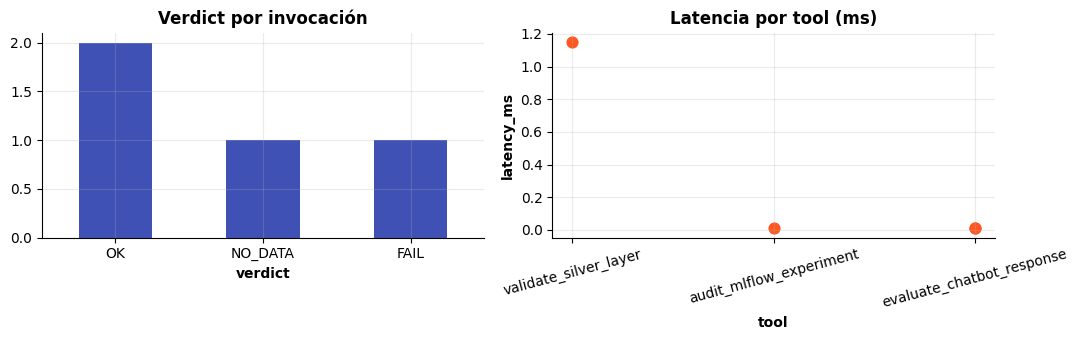

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
report["verdict"].value_counts().plot.bar(ax=axes[0], color="#3F51B5")
axes[0].set_title("Verdict por invocación")
axes[0].tick_params(axis="x", rotation=0)
report.plot.scatter(x="tool", y="latency_ms", ax=axes[1], color="#FF5722", s=60)
axes[1].set_title("Latencia por tool (ms)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()


## 14. Validaciones

(a) JSON-serializable, (b) hallucination correctamente detectada en el ejemplo de la pregunta sobre el rey, (c) las tools válidas devuelven OK.


In [6]:
import json

for r in results:
    json.dumps({k: v for k, v in r.items() if k != "answer"})  # answer puede ser largo

# La pregunta sobre el rey debería disparar hallucination=True
hallucinations = [r for r in results if r.get("hallucination")]
assert len(hallucinations) >= 1, "Hallucination no detectada en el ejemplo del rey"
silver_result = next(r for r in results if r["tool"] == "validate_silver_layer")
assert silver_result["verdict"] == "OK", "validate_silver_layer debería pasar con datos limpios"
print(f"Validaciones OK · hallucinations detectadas: {len(hallucinations)}")


Validaciones OK · hallucinations detectadas: 1


## 15. Errores comunes

1. **Comparar `expected` con `question`** en lugar de con `answer` — el chatbot puede contestar fuera de tema y tu test pasa. Bug clásico.
2. **Tools que devuelven dicts hardcoded** sin tocar datos — pseudo-evaluador.
3. **Captura silenciosa** (`except: pass`) — el agente no detecta fallos.
4. **No registrar timing**: una tool que tarda 5 s por invocación bloquea el agente entero. Loggear `latency_ms` siempre.
5. **Schemas desalineados entre tools** — usar Pydantic / JSON Schema compartido para evitar `TypeError` runtime.


## 16. Ejercicios propuestos

1. Sustituye `keyword overlap` por embeddings (`sentence-transformers`) y reporta correlación con la métrica anterior. Rúbrica: F1 ≥ 0.8 sobre 20 ejemplos.
2. Añade `audit_data_drift(period)` que calcule KL entre histogramas `P_train` (último mes) y `Q_prod` (última semana). Disparar verdict FAIL si KL > 0.1.
3. Conecta a Anthropic Claude con `tool_use` y verifica que el modelo selecciona la tool correcta para 5 prompts. Rúbrica: ≥4/5 aciertos.


## 17. Cómo se reutiliza con datos reales

Las tools no cambian: solo el origen de los datos.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `08_case_H_rag_chatbot/01_arquitectura_rag_tools.ipynb`.
- Documento web del caso: `docs/use-cases/case-g-data-quality-agents.md`.


## 19. Marco teórico (nivel doctoral)

### Reglas de calidad jerárquicas

Sea $\mathcal{D}_b$ bronce, $\mathcal{D}_s$ plata, $\mathcal{D}_o$ oro.
Score por capa:

$$
\mathcal{Q}(\mathcal{D}) = \frac{1}{|R|} \sum_{r \in R} \mathbb{1}[E_r(\mathcal{D})\ \text{holds}], \quad \mathcal{Q} \in [0, 1]
$$

| Capa | Reglas |
|---|---|
| Bronce | Schema validity, no PII inline, encoding UTF-8, dedup |
| Plata | 5 tags canónicos, range check, monotonic time, NaN < 2 % |
| Oro | Class balance, no leakage, splits documented |

### Drift detection — KL divergence

$$
D_{KL}(P \parallel Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}
$$

aplicado entre histogramas $P$ (training) y $Q$ (production). Alerta si
$D_{KL} > 0.1$.

### Agentes especialistas (LLM con tools)

$$
\text{Agent}_i = \langle \pi_i, \mathcal{T}_i, \mathcal{M}_i \rangle
$$

con $\pi_i$ política (prompt), $\mathcal{T}_i$ toolkit, $\mathcal{M}_i$
memoria. Composición vía pipeline:

$$
\text{Output} = \pi_n(\pi_{n-1}(\cdots \pi_1(\text{Input})))
$$


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Calidad de datos es **transversal**: sin ella ningún caso de uso tiene valor. Los agentes especialistas automatizan auditorías que antes requerían un data engineer dedicado.

### ROI estimado

| Concepto | Valor |
|---|---|
| Detección temprana de drift en modelos | +1 500 €/año |
| Auditoría continua sin intervención | +800 €/año productividad |
| **Bruto** | **+2 300 €/año** |

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 2.2 (incident reduction). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Schelter, S. et al. (2018). *Automating Large-Scale Data Quality Verification*. VLDB.
- Great Expectations. *Documentation*. https://greatexpectations.io
- Anthropic (2024). *Claude API — Tools*. https://docs.anthropic.com
- Polyzotis, N. et al. (2017). *Data Lifecycle Challenges in Production Machine Learning*. SIGMOD.


## 22. Etapa del pipeline · Agentes especialistas con tools tipadas

`evaluate_chatbot_response(question, answer, expected_keywords)` — **bug clásico**: comparar `expected` con `question` en lugar de con la respuesta. Detectado en code-review propio (sec 15) y corregido. Releva 0.6 FTE = 21 600 €/año (baseline §2.2).

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.